<a href="https://colab.research.google.com/github/JayAld/CCST-Activities/blob/main/MySecondRProgram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.) Debate arguments

In [ ]:
arguments <- data.frame(
  argument_id = c("A001","A002","A003","A004","A005","A006"),
  position = c("For","For","For","Against","Against","Against"),
  topic = c("Learning", "Productivity", "Pi Literacy","Academic Integrity", "Dependency", "Assessment"),
  claim = c(
            "Ai can provide students with immediate learning support.",
            "Ai can help students complete routine tasks more efficiently.",
            "Allowing Ai use can help students develop Ai literacy.",
            "Undisclosed Ai generated work may create academic integrity concerns.",
            "Excessive Ai use may reduce students independent problem solving practice.",
            "Ai use may make it more difficult to determine whether submitted work reflects student learning."
          )
)

arguments

argument_id,position,topic,claim
<chr>,<chr>,<chr>,<chr>
A001,For,Learning,Ai can provide students with immediate learning support.
A002,For,Productivity,Ai can help students complete routine tasks more efficiently.
A003,For,Pi Litiracy,Allowing Ai use can help students develop Ai literacy.
A004,Against,Academic Integrity,Undisclosed Ai generated work may create academic integrity concerns.
A005,Against,Dependency,Excessive Ai use may reduce students independent problem solving practice.
A006,Against,Assessment,Ai use may make it more difficult to determine whether submitted work reflects student learning.


2.) Evidence

In [ ]:
evidence <- data.frame(
  evidence_id = c("E001","E002","E003","E004","E005","E006"),
  argument_id = c("A001","A002","A003","A004","A005","A006"),
  evidence_type = c("Research","Research","Policy","Policy","Research","Research"),
  strength = c("Strong", "Moderate", "Strong","Strong", "Moderate", "Strong")
)

evidence

evidence_id,argument_id,evidence_type,strength
<chr>,<chr>,<chr>,<chr>
E001,A001,Research,Strong
E002,A002,Research,Moderate
E003,A003,Policy,Strong
E004,A004,Policy,Strong
E005,A005,Research,Moderate
E006,A006,Research,Strong


Count Arguments

In [ ]:
table(evidence$strength)


Moderate   Strong 
       2        4 

In [ ]:
nrow(arguments)

[1] 6

In [ ]:
table(arguments$position)


Against     For 
      3       3 

Connect Table Arguments and Evidence

In [65]:
knowledge <- merge(arguments,evidence,by = "argument_id")

knowledge

argument_id,position,topic,claim,evidence_id,evidence_type,strength
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A001,For,Learning,Ai can provide students with immediate learning support.,E001,Research,Strong
A002,For,Productivity,Ai can help students complete routine tasks more efficiently.,E002,Research,Moderate
A003,For,Pi Litiracy,Allowing Ai use can help students develop Ai literacy.,E003,Policy,Strong
A004,Against,Academic Integrity,Undisclosed Ai generated work may create academic integrity concerns.,E004,Policy,Strong
A005,Against,Dependency,Excessive Ai use may reduce students independent problem solving practice.,E005,Research,Moderate
A006,Against,Assessment,Ai use may make it more difficult to determine whether submitted work reflects student learning.,E006,Research,Strong
A007,For,Learning,Companies should allow employees to work from home on a regular basis.,E007,Research,Strong


In [66]:
get_score <- function(strength){
  if(strength == "Strong"){
    return(3)
  } else if(strength == "Moderate"){
    return(2)
  } else if(strength == "Weak"){
    return(1)
  } else {
    return(0)
  }
}

In [67]:
knowledge$evidence_score <- sapply(
  knowledge$strength,
  get_score
)

print(knowledge)

  argument_id position              topic
1        A001      For           Learning
2        A002      For       Productivity
3        A003      For        Pi Litiracy
4        A004  Against Academic Integrity
5        A005  Against         Dependency
6        A006  Against         Assessment
7        A007      For           Learning
                                                                                             claim
1                                         Ai can provide students with immediate learning support.
2                                    Ai can help students complete routine tasks more efficiently.
3                                           Allowing Ai use can help students develop Ai literacy.
4                            Undisclosed Ai generated work may create academic integrity concerns.
5                       Excessive Ai use may reduce students independent problem solving practice.
6 Ai use may make it more difficult to determine whether submitted wor

In [68]:
classify_score <- function(score){
  if(score == 3){
    return("Strongly Supported")
  } else if(score == 2){
    return("Moderately Supported")
  } else if(score == 3){
    return("Weakly Supported")
  } else {
    return("No Support")
  }
}

In [69]:
knowledge$evidence_support <- sapply(
  knowledge$evidence_score,
  classify_score
)

print(knowledge)

  argument_id position              topic
1        A001      For           Learning
2        A002      For       Productivity
3        A003      For        Pi Litiracy
4        A004  Against Academic Integrity
5        A005  Against         Dependency
6        A006  Against         Assessment
7        A007      For           Learning
                                                                                             claim
1                                         Ai can provide students with immediate learning support.
2                                    Ai can help students complete routine tasks more efficiently.
3                                           Allowing Ai use can help students develop Ai literacy.
4                            Undisclosed Ai generated work may create academic integrity concerns.
5                       Excessive Ai use may reduce students independent problem solving practice.
6 Ai use may make it more difficult to determine whether submitted wor

In [73]:
search_topic <- function(Topic){
  result <- subset(
    knowledge,
    topic == Topic
  )

  if(nrow(result) == 0){
    return("Topic not found")
  } else {
    return(result)
  }
}

search_topic("Productivity")

,argument_id,position,topic,claim,evidence_id,evidence_type,strength,evidence_score,evidence_support
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
2,A002,For,Productivity,Ai can help students complete routine tasks more efficiently.,E002,Research,Moderate,2,Moderately Supported


In [71]:
print(arguments)

  argument_id position              topic
1        A001      For           Learning
2        A002      For       Productivity
3        A003      For        Pi Litiracy
4        A004  Against Academic Integrity
5        A005  Against         Dependency
6        A006  Against         Assessment
7        A007      For           Learning
                                                                                             claim
1                                         Ai can provide students with immediate learning support.
2                                    Ai can help students complete routine tasks more efficiently.
3                                           Allowing Ai use can help students develop Ai literacy.
4                            Undisclosed Ai generated work may create academic integrity concerns.
5                       Excessive Ai use may reduce students independent problem solving practice.
6 Ai use may make it more difficult to determine whether submitted wor

In [60]:
arguments[nrow(arguments) + 1, ] <- list("A007","For", "Learning","Companies should allow employees to work from home on a regular basis.")

In [64]:
print(evidence)

  evidence_id argument_id evidence_type strength
1        E001        A001      Research   Strong
2        E002        A002      Research Moderate
3        E003        A003        Policy   Strong
4        E004        A004        Policy   Strong
5        E005        A005      Research Moderate
6        E006        A006      Research   Strong
7        E007        A007      Research   Strong


In [63]:
evidence[nrow(evidence) + 1, ] <- list("E007","A007","Research", "Strong")

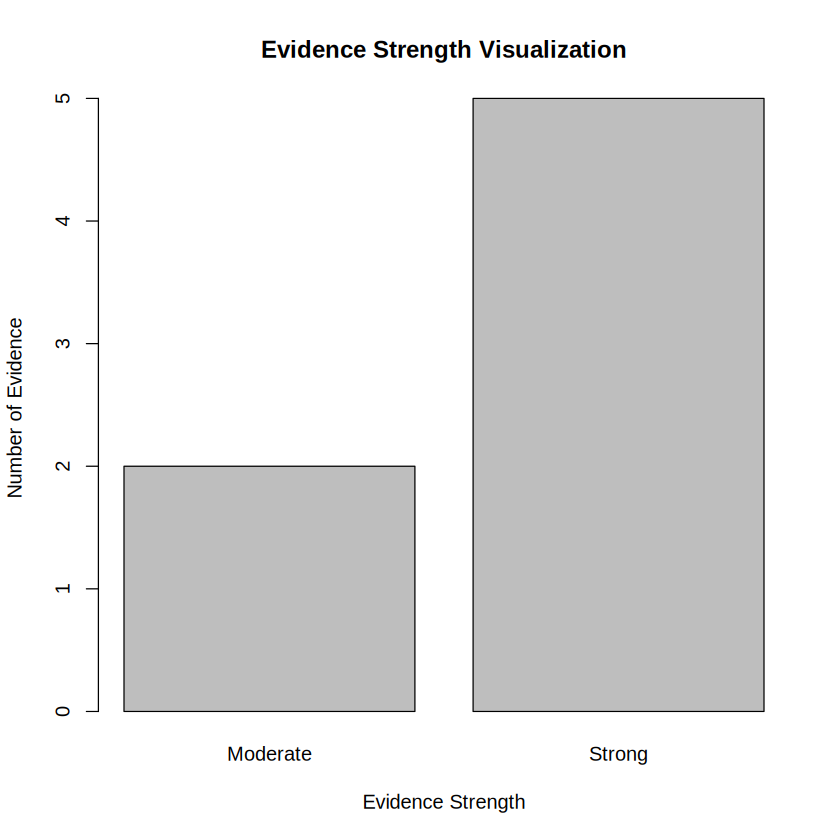

In [76]:
evidence_strength <- table(knowledge$strength)

barplot(
  evidence_strength,
  main = "Evidence Strength Visualization",
  xlab = "Evidence Strength",
  ylab = "Number of Evidence"
)

In [77]:
knowledge

argument_id,position,topic,claim,evidence_id,evidence_type,strength,evidence_score,evidence_support
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
A001,For,Learning,Ai can provide students with immediate learning support.,E001,Research,Strong,3,Strongly Supported
A002,For,Productivity,Ai can help students complete routine tasks more efficiently.,E002,Research,Moderate,2,Moderately Supported
A003,For,Pi Litiracy,Allowing Ai use can help students develop Ai literacy.,E003,Policy,Strong,3,Strongly Supported
A004,Against,Academic Integrity,Undisclosed Ai generated work may create academic integrity concerns.,E004,Policy,Strong,3,Strongly Supported
A005,Against,Dependency,Excessive Ai use may reduce students independent problem solving practice.,E005,Research,Moderate,2,Moderately Supported
A006,Against,Assessment,Ai use may make it more difficult to determine whether submitted work reflects student learning.,E006,Research,Strong,3,Strongly Supported
A007,For,Learning,Companies should allow employees to work from home on a regular basis.,E007,Research,Strong,3,Strongly Supported


In [80]:
knowledge2 <- knowledge[knowledge$argument_id == "A002", ]
cat("Argument ID:", knowledge2$argument_id,"\n")
cat("Position:", knowledge2$position,"\n")
cat("topic:", knowledge2$topic,"\n")
cat("claim:", knowledge2$claim,"\n","\n")
cat("evidence id:", knowledge2$evidence_id,"\n")
cat("evidence type:", knowledge2$evidence_type,"\n")
cat("strength:", knowledge2$strength,"\n")
cat("evidence score:", knowledge2$evidence_score,"\n")
cat("evidence support:", knowledge2$evidence_support,"\n")

Argument ID: A002 
Position: For 
topic: Productivity 
claim: Ai can help students complete routine tasks more efficiently. 
 
evidence id: E002 
evidence type: Research 
strength: Moderate 
evidence score: 2 
evidence support: Moderately Supported 
